In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
data = pd.read_csv("../data/ibtracs.NA.list.v04r01.csv", skiprows=[1], low_memory=False)
hurricane_df = data.drop(data[data["SEASON"] < 1980].index)

hurricane_df = hurricane_df.replace(r"^\s*$", np.nan, regex=True)

/tmp/ipykernel_61578/1552510637.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hurricane_df = hurricane_df.replace(r"^\s*$", np.nan, regex=True)


In [3]:
hurricane_df = hurricane_df.drop(columns=hurricane_df.columns[(hurricane_df.isna().sum() / len(hurricane_df) > 0.5)])
hurricane_df = hurricane_df.drop(columns=["USA_LAT", "USA_LON", "WMO_WIND"])

In [4]:
hurricane_df

,SID,SEASON,NUMBER,NAME,ISO_TIME,NATURE,LAT,LON,WMO_AGENCY,TRACK_TYPE,...,USA_ATCF_ID,USA_STATUS,USA_WIND,USA_PRES,USA_SSHS,USA_POCI,USA_ROCI,USA_RMW,STORM_SPEED,STORM_DIR
85538,1980199N31284,1980,47,UNNAMED,1980-07-17 00:00:00,TS,30.5,-76.5,hurdat_atl,main,...,AL011980,TD,20,NaN,-1,NaN,NaN,NaN,7,245
85539,1980199N31284,1980,47,UNNAMED,1980-07-17 03:00:00,TS,30.3,-76.9,NaN,main,...,AL011980,TD,23,NaN,-1,NaN,NaN,NaN,7,245
85540,1980199N31284,1980,47,UNNAMED,1980-07-17 06:00:00,TS,30.2,-77.2,hurdat_atl,main,...,AL011980,TD,25,NaN,-1,NaN,NaN,NaN,7,245
85541,1980199N31284,1980,47,UNNAMED,1980-07-17 09:00:00,TS,30.1,-77.6,NaN,main,...,AL011980,TD,25,NaN,-1,NaN,NaN,NaN,7,255
85542,1980199N31284,1980,47,UNNAMED,1980-07-17 12:00:00,TS,30.0,-78.0,hurdat_atl,main,...,AL011980,TD,25,NaN,-1,NaN,NaN,NaN,10,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127240,2026241N30273,2026,61,EDOUARD,2026-09-02 18:00:00,DS,31.4,-95.1,NaN,PROVISIONAL,...,AL052026,DB,20,1011,-3,1013,80,25,4,345
127241,2026241N30273,2026,61,EDOUARD,2026-09-02 21:00:00,DS,31.7,-95.2,NaN,PROVISIONAL,...,AL052026,DB,20,1011,-3,1013,65,28,7,330
127242,2026241N30273,2026,61,EDOUARD,2026-09-03 00:00:00,DS,32.0,-95.5,NaN,PROVISIONAL,...,AL052026,DB,20,1011,-3,1012,50,30,8,315
127243,2026241N30273,2026,61,EDOUARD,2026-09-03 03:00:00,DS,32.2,-95.9,NaN,PROVISIONAL,...,AL052026,DB,20,1012,-3,1012,53,40,8,300


In [5]:
hurricane_df = hurricane_df.astype(
    {
        "SID" : "string",
        "SEASON" : "Int16",
        "NUMBER" : "Int16",
        "NAME" : "string",
        "ISO_TIME" : "datetime64[ns]",
        "NATURE" : "category",
        "LAT" : "float32",
        "LON" : "float32",
        "WMO_AGENCY" : "category",
        "TRACK_TYPE" : "category",
        "DIST2LAND" : "Int16",
        "LANDFALL" : "Int16",
        "IFLAG" : "category",
        "USA_AGENCY" : "category",
        "USA_ATCF_ID" : "string",
        "USA_STATUS" : "category",
        "USA_WIND" : "Int16",
        "USA_PRES" : "Int16",
        "USA_SSHS" : "category",
        "USA_POCI" : "Int16",
        "USA_ROCI" : "Int16",
        "USA_RMW" : "Int16",
        "STORM_SPEED" : "Int16",
        "STORM_DIR" : "Int16",
    }
)

hurricane_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41707 entries, 85538 to 127244
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   SID          41707 non-null  string        
 1   SEASON       41707 non-null  Int16         
 2   NUMBER       41707 non-null  Int16         
 3   NAME         41707 non-null  string        
 4   ISO_TIME     41707 non-null  datetime64[ns]
 5   NATURE       41707 non-null  category      
 6   LAT          41707 non-null  float32       
 7   LON          41707 non-null  float32       
 8   WMO_AGENCY   21439 non-null  category      
 9   TRACK_TYPE   41707 non-null  category      
 10  DIST2LAND    41707 non-null  Int16         
 11  LANDFALL     40959 non-null  Int16         
 12  IFLAG        41707 non-null  category      
 13  USA_AGENCY   21545 non-null  category      
 14  USA_ATCF_ID  41707 non-null  string        
 15  USA_STATUS   41707 non-null  category      
 16 

In [6]:
hurricane_df.duplicated().sum()

np.int64(0)

In [7]:
hurricane_df.shape

(41707, 24)

In [8]:
hurricane_df["DELTA_LAT"] = hurricane_df.groupby("SID")["LAT"].diff().round(1)
hurricane_df["DELTA_LON"] = hurricane_df.groupby("SID")["LON"].diff().round(1)

hurricane_df["LAT_ACCELERATION"] = hurricane_df.groupby("SID")["DELTA_LAT"].diff().round(1)
hurricane_df["LON_ACCELERATION"] = hurricane_df.groupby("SID")["DELTA_LON"].diff().round(1)

hurricane_df["WIND_CHANGE"] = hurricane_df.groupby("SID")["USA_WIND"].diff()
hurricane_df["PRES_CHANGE"] = hurricane_df.groupby("SID")["USA_PRES"].diff()

hurricane_df["WIND_ACCELERATION"] = hurricane_df.groupby("SID")["WIND_CHANGE"].diff()
hurricane_df["PRES_ACCELERATION"] = hurricane_df.groupby("SID")["PRES_CHANGE"].diff()

hurricane_df
#hurricane_df["NATURE"].value_counts()

,SID,SEASON,NUMBER,NAME,ISO_TIME,NATURE,LAT,LON,WMO_AGENCY,TRACK_TYPE,...,STORM_SPEED,STORM_DIR,DELTA_LAT,DELTA_LON,LAT_ACCELERATION,LON_ACCELERATION,WIND_CHANGE,PRES_CHANGE,WIND_ACCELERATION,PRES_ACCELERATION
85538,1980199N31284,1980,47,UNNAMED,1980-07-17 00:00:00,TS,30.500000,-76.500000,hurdat_atl,main,...,7,245,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
85539,1980199N31284,1980,47,UNNAMED,1980-07-17 03:00:00,TS,30.299999,-76.900002,NaN,main,...,7,245,-0.2,-0.4,NaN,NaN,3,<NA>,<NA>,<NA>
85540,1980199N31284,1980,47,UNNAMED,1980-07-17 06:00:00,TS,30.200001,-77.199997,hurdat_atl,main,...,7,245,-0.1,-0.3,0.1,0.1,2,<NA>,-1,<NA>
85541,1980199N31284,1980,47,UNNAMED,1980-07-17 09:00:00,TS,30.100000,-77.599998,NaN,main,...,7,255,-0.1,-0.4,0.0,-0.1,0,<NA>,-2,<NA>
85542,1980199N31284,1980,47,UNNAMED,1980-07-17 12:00:00,TS,30.000000,-78.000000,hurdat_atl,main,...,10,260,-0.1,-0.4,0.0,0.0,0,<NA>,0,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127240,2026241N30273,2026,61,EDOUARD,2026-09-02 18:00:00,DS,31.400000,-95.099998,NaN,PROVISIONAL,...,4,345,0.1,0.0,0.0,0.0,-5,3,0,-1
127241,2026241N30273,2026,61,EDOUARD,2026-09-02 21:00:00,DS,31.700001,-95.199997,NaN,PROVISIONAL,...,7,330,0.3,-0.1,0.2,-0.1,0,0,5,-3
127242,2026241N30273,2026,61,EDOUARD,2026-09-03 00:00:00,DS,32.000000,-95.500000,NaN,PROVISIONAL,...,8,315,0.3,-0.3,0.0,-0.2,0,0,0,0
127243,2026241N30273,2026,61,EDOUARD,2026-09-03 03:00:00,DS,32.200001,-95.900002,NaN,PROVISIONAL,...,8,300,0.2,-0.4,-0.1,-0.1,0,1,0,1


In [9]:
hurricane_df.isna().sum().sort_values(ascending=False) / len(hurricane_df)

WMO_AGENCY           0.485962
USA_AGENCY           0.483420
USA_ROCI             0.477546
USA_RMW              0.474477
USA_POCI             0.473494
PRES_ACCELERATION    0.074568
PRES_CHANGE          0.057928
USA_PRES             0.041288
WIND_ACCELERATION    0.036684
LON_ACCELERATION     0.035869
LAT_ACCELERATION     0.035869
WIND_CHANGE          0.018750
DELTA_LON            0.017935
DELTA_LAT            0.017935
LANDFALL             0.017935
USA_WIND             0.000815
USA_STATUS           0.000000
USA_ATCF_ID          0.000000
IFLAG                0.000000
DIST2LAND            0.000000
TRACK_TYPE           0.000000
NATURE               0.000000
LAT                  0.000000
LON                  0.000000
NAME                 0.000000
NUMBER               0.000000
SEASON               0.000000
ISO_TIME             0.000000
SID                  0.000000
STORM_DIR            0.000000
USA_SSHS             0.000000
STORM_SPEED          0.000000
dtype: float64

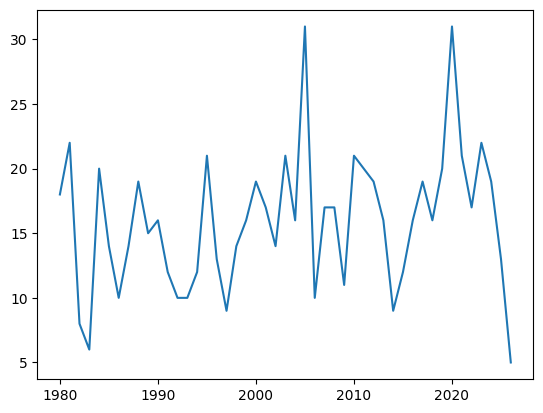

In [10]:
hurricanes_per_year = (
    hurricane_df
    .groupby("SEASON")["SID"]
    .nunique()
)

plt.plot(hurricanes_per_year)

In [11]:
hurricane_df["MONTH"] = hurricane_df["ISO_TIME"].dt.month.astype("Int16")

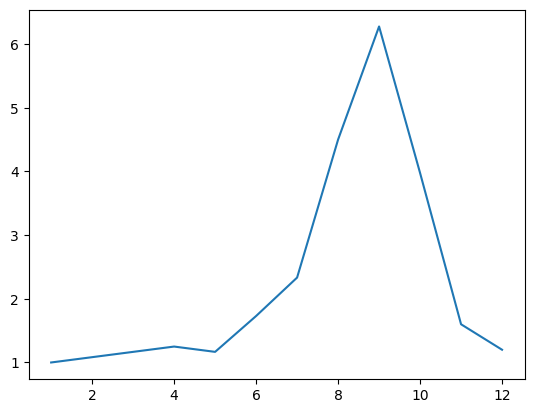

In [12]:
hurricanes_per_month = (
    hurricane_df.groupby(["SEASON", "MONTH"])["SID"]
    .nunique()
)

hurricane_monthly_average = hurricanes_per_month.groupby("MONTH").mean()

plt.plot(hurricane_monthly_average)

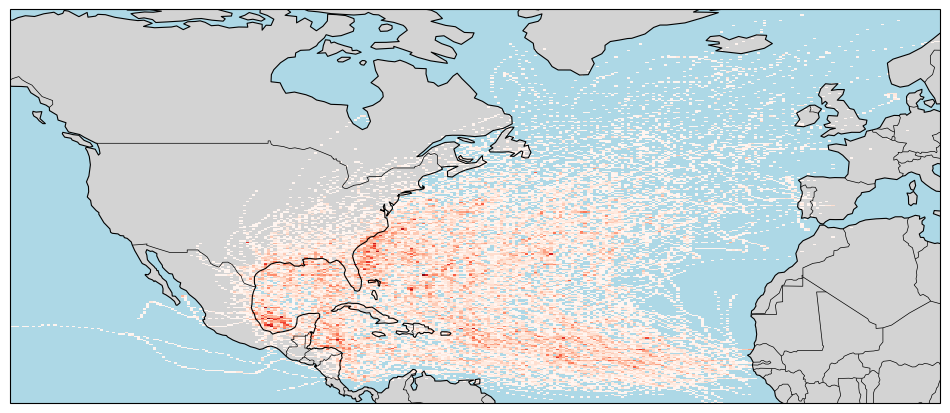

In [13]:
cmap = plt.cm.Reds.copy()
cmap.set_under(alpha=0)

plt.figure(figsize=(12, 12))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-100, -70, 15, 45], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

hist = ax.hist2d(
    hurricane_df["LON"],
    hurricane_df["LAT"],
    bins=300,
    cmap=cmap,
    vmin=1,
    transform=ccrs.PlateCarree()
)


In [14]:
print(hurricane_df["TRACK_TYPE"].value_counts())

hurricane_df

TRACK_TYPE
main           41500
PROVISIONAL      207
Name: count, dtype: int64


,SID,SEASON,NUMBER,NAME,ISO_TIME,NATURE,LAT,LON,WMO_AGENCY,TRACK_TYPE,...,STORM_DIR,DELTA_LAT,DELTA_LON,LAT_ACCELERATION,LON_ACCELERATION,WIND_CHANGE,PRES_CHANGE,WIND_ACCELERATION,PRES_ACCELERATION,MONTH
85538,1980199N31284,1980,47,UNNAMED,1980-07-17 00:00:00,TS,30.500000,-76.500000,hurdat_atl,main,...,245,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,7
85539,1980199N31284,1980,47,UNNAMED,1980-07-17 03:00:00,TS,30.299999,-76.900002,NaN,main,...,245,-0.2,-0.4,NaN,NaN,3,<NA>,<NA>,<NA>,7
85540,1980199N31284,1980,47,UNNAMED,1980-07-17 06:00:00,TS,30.200001,-77.199997,hurdat_atl,main,...,245,-0.1,-0.3,0.1,0.1,2,<NA>,-1,<NA>,7
85541,1980199N31284,1980,47,UNNAMED,1980-07-17 09:00:00,TS,30.100000,-77.599998,NaN,main,...,255,-0.1,-0.4,0.0,-0.1,0,<NA>,-2,<NA>,7
85542,1980199N31284,1980,47,UNNAMED,1980-07-17 12:00:00,TS,30.000000,-78.000000,hurdat_atl,main,...,260,-0.1,-0.4,0.0,0.0,0,<NA>,0,<NA>,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127240,2026241N30273,2026,61,EDOUARD,2026-09-02 18:00:00,DS,31.400000,-95.099998,NaN,PROVISIONAL,...,345,0.1,0.0,0.0,0.0,-5,3,0,-1,9
127241,2026241N30273,2026,61,EDOUARD,2026-09-02 21:00:00,DS,31.700001,-95.199997,NaN,PROVISIONAL,...,330,0.3,-0.1,0.2,-0.1,0,0,5,-3,9
127242,2026241N30273,2026,61,EDOUARD,2026-09-03 00:00:00,DS,32.000000,-95.500000,NaN,PROVISIONAL,...,315,0.3,-0.3,0.0,-0.2,0,0,0,0,9
127243,2026241N30273,2026,61,EDOUARD,2026-09-03 03:00:00,DS,32.200001,-95.900002,NaN,PROVISIONAL,...,300,0.2,-0.4,-0.1,-0.1,0,1,0,1,9


<GeoAxes: xlabel='LON', ylabel='LAT'>

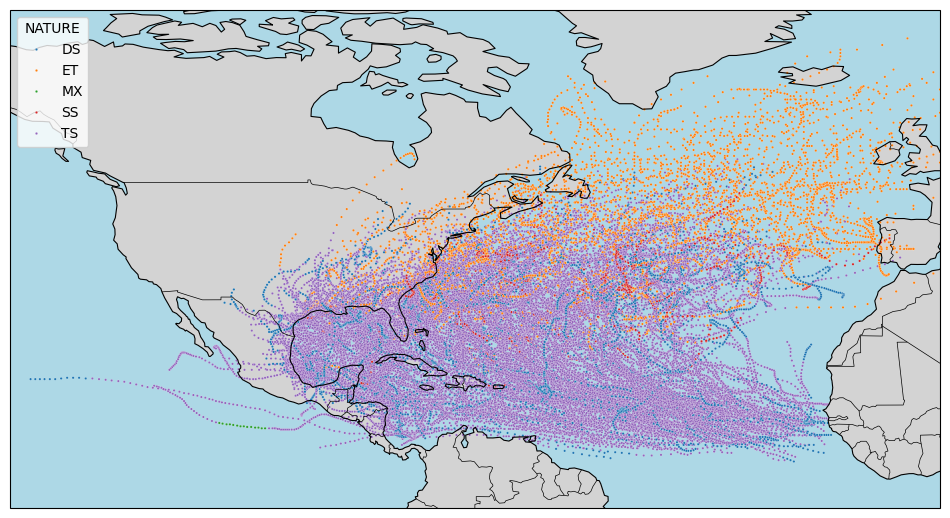

In [15]:
plt.figure(figsize=(12, 12))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-140, 0, 0, 75], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

sns.scatterplot(x="LON", y="LAT", data=hurricane_df, hue="NATURE", s=3, ax=ax)

<GeoAxes: xlabel='LON', ylabel='LAT'>

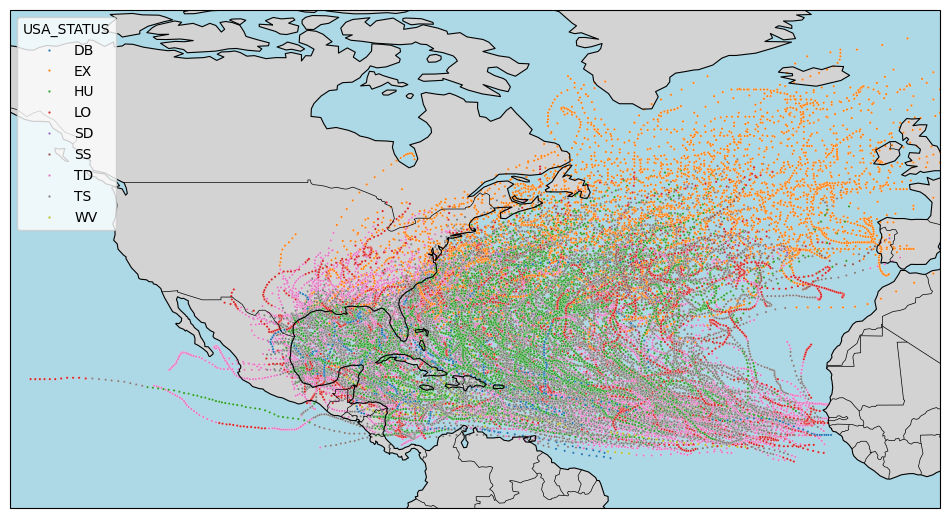

In [16]:
plt.figure(figsize=(12, 12))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-140, 0, 0, 75], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

sns.scatterplot(x="LON", y="LAT", data=hurricane_df, hue="USA_STATUS", s=3, ax=ax)

<GeoAxes: xlabel='LON', ylabel='LAT'>

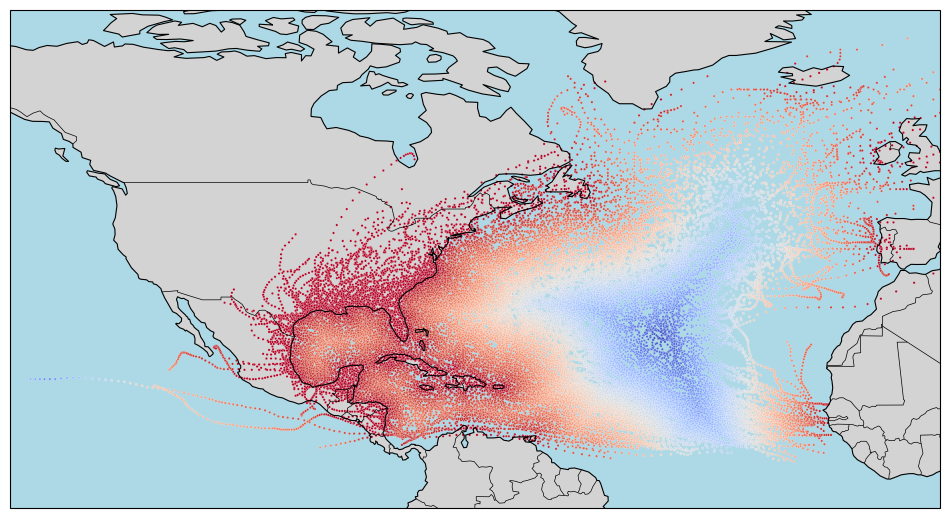

In [17]:
plt.figure(figsize=(12, 12))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-140, 0, 0, 75], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

sns.scatterplot(x="LON", y="LAT", data=hurricane_df, c=hurricane_df["DIST2LAND"], s=3, cmap="coolwarm_r", ax=ax)

<GeoAxes: xlabel='LON', ylabel='LAT'>

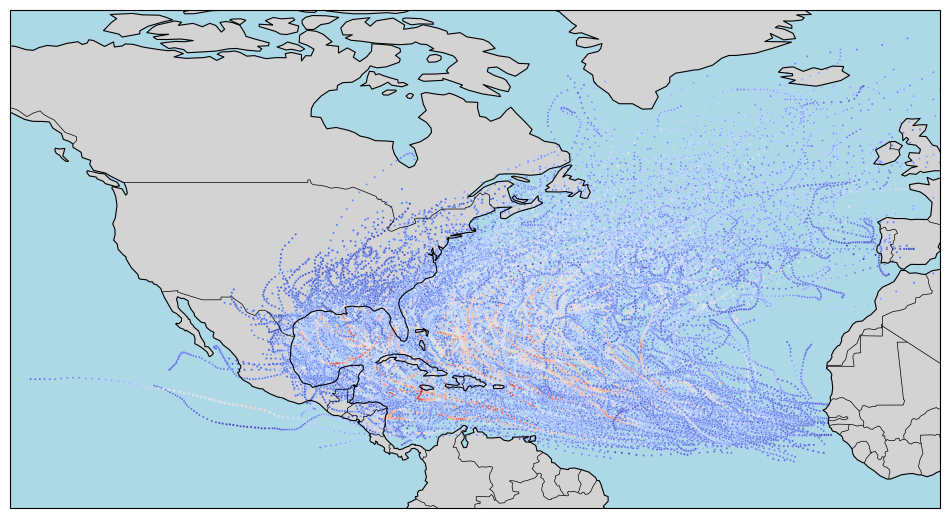

In [18]:
plt.figure(figsize=(12, 12))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-140, 0, 0, 75], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

sns.scatterplot(x="LON", y="LAT", data=hurricane_df, c=hurricane_df["USA_WIND"], s=3, cmap="coolwarm", ax=ax)

<GeoAxes: xlabel='LON', ylabel='LAT'>

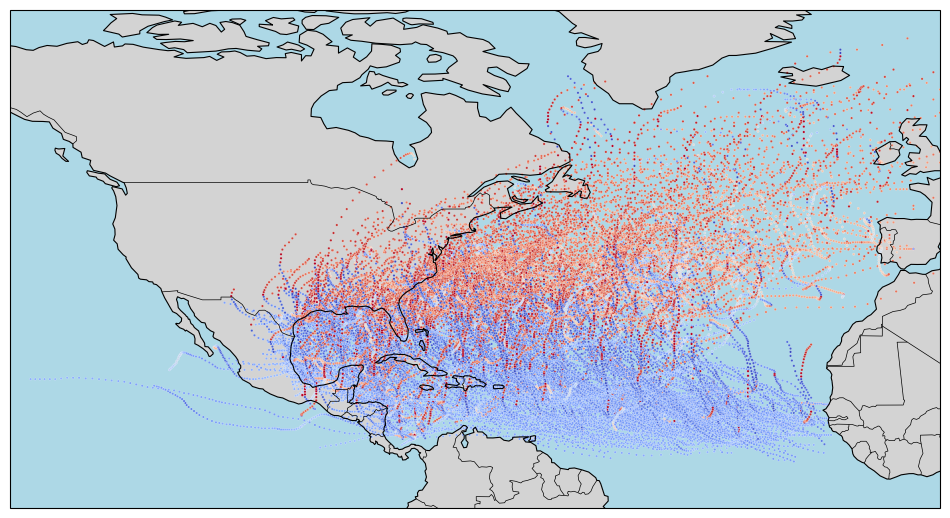

In [19]:
plt.figure(figsize=(12, 12))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-140, 0, 0, 75], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

sns.scatterplot(x="LON", y="LAT", data=hurricane_df, c=hurricane_df["STORM_DIR"], s=3, cmap="coolwarm_r", ax=ax)

<GeoAxes: xlabel='LON', ylabel='LAT'>

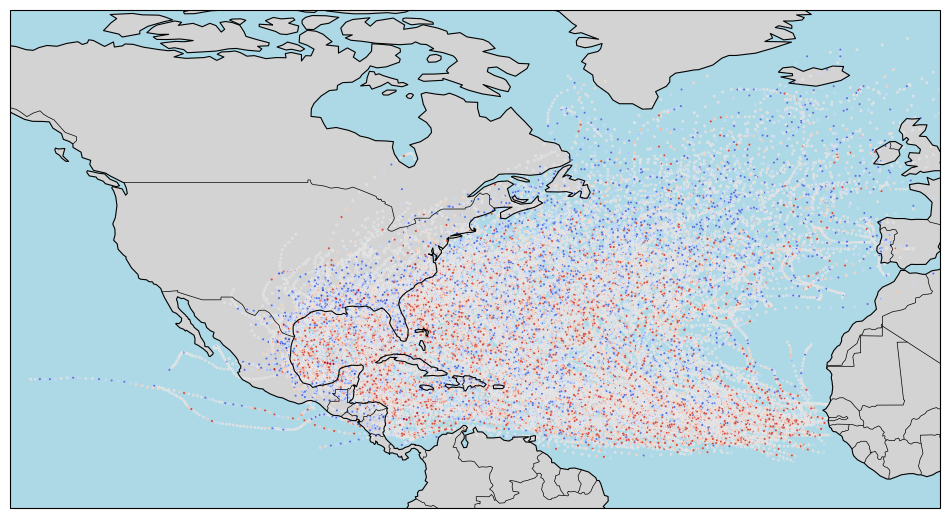

In [20]:
plt.figure(figsize=(12, 12))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-140, 0, 0, 75], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

sns.scatterplot(x="LON", y="LAT", data=hurricane_df, c=(hurricane_df["WIND_CHANGE"] * 10) ** 3, s=3, cmap="coolwarm", ax=ax)

/home/sgeforever/.pyenv/versions/stuff-env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
/home/sgeforever/.pyenv/versions/stuff-env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)


<GeoAxes: xlabel='LON', ylabel='LAT'>

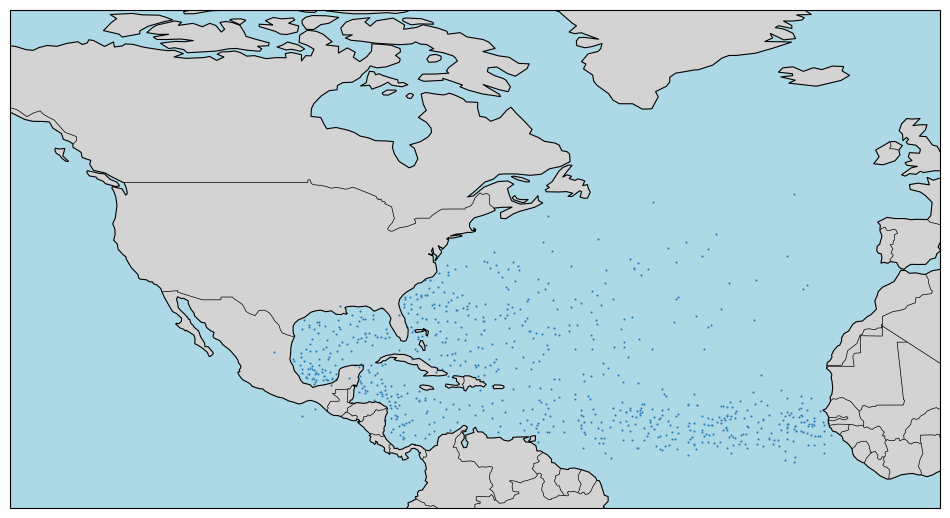

In [ ]:
#every hurricane step by step

plt.figure(figsize=(12, 12))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-140, 0, 0, 75], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

sns.scatterplot(x="LON", y="LAT", data=hurricane_df.groupby("SID").first(), s=3, cmap="coolwarm", ax=ax)

<Axes: >

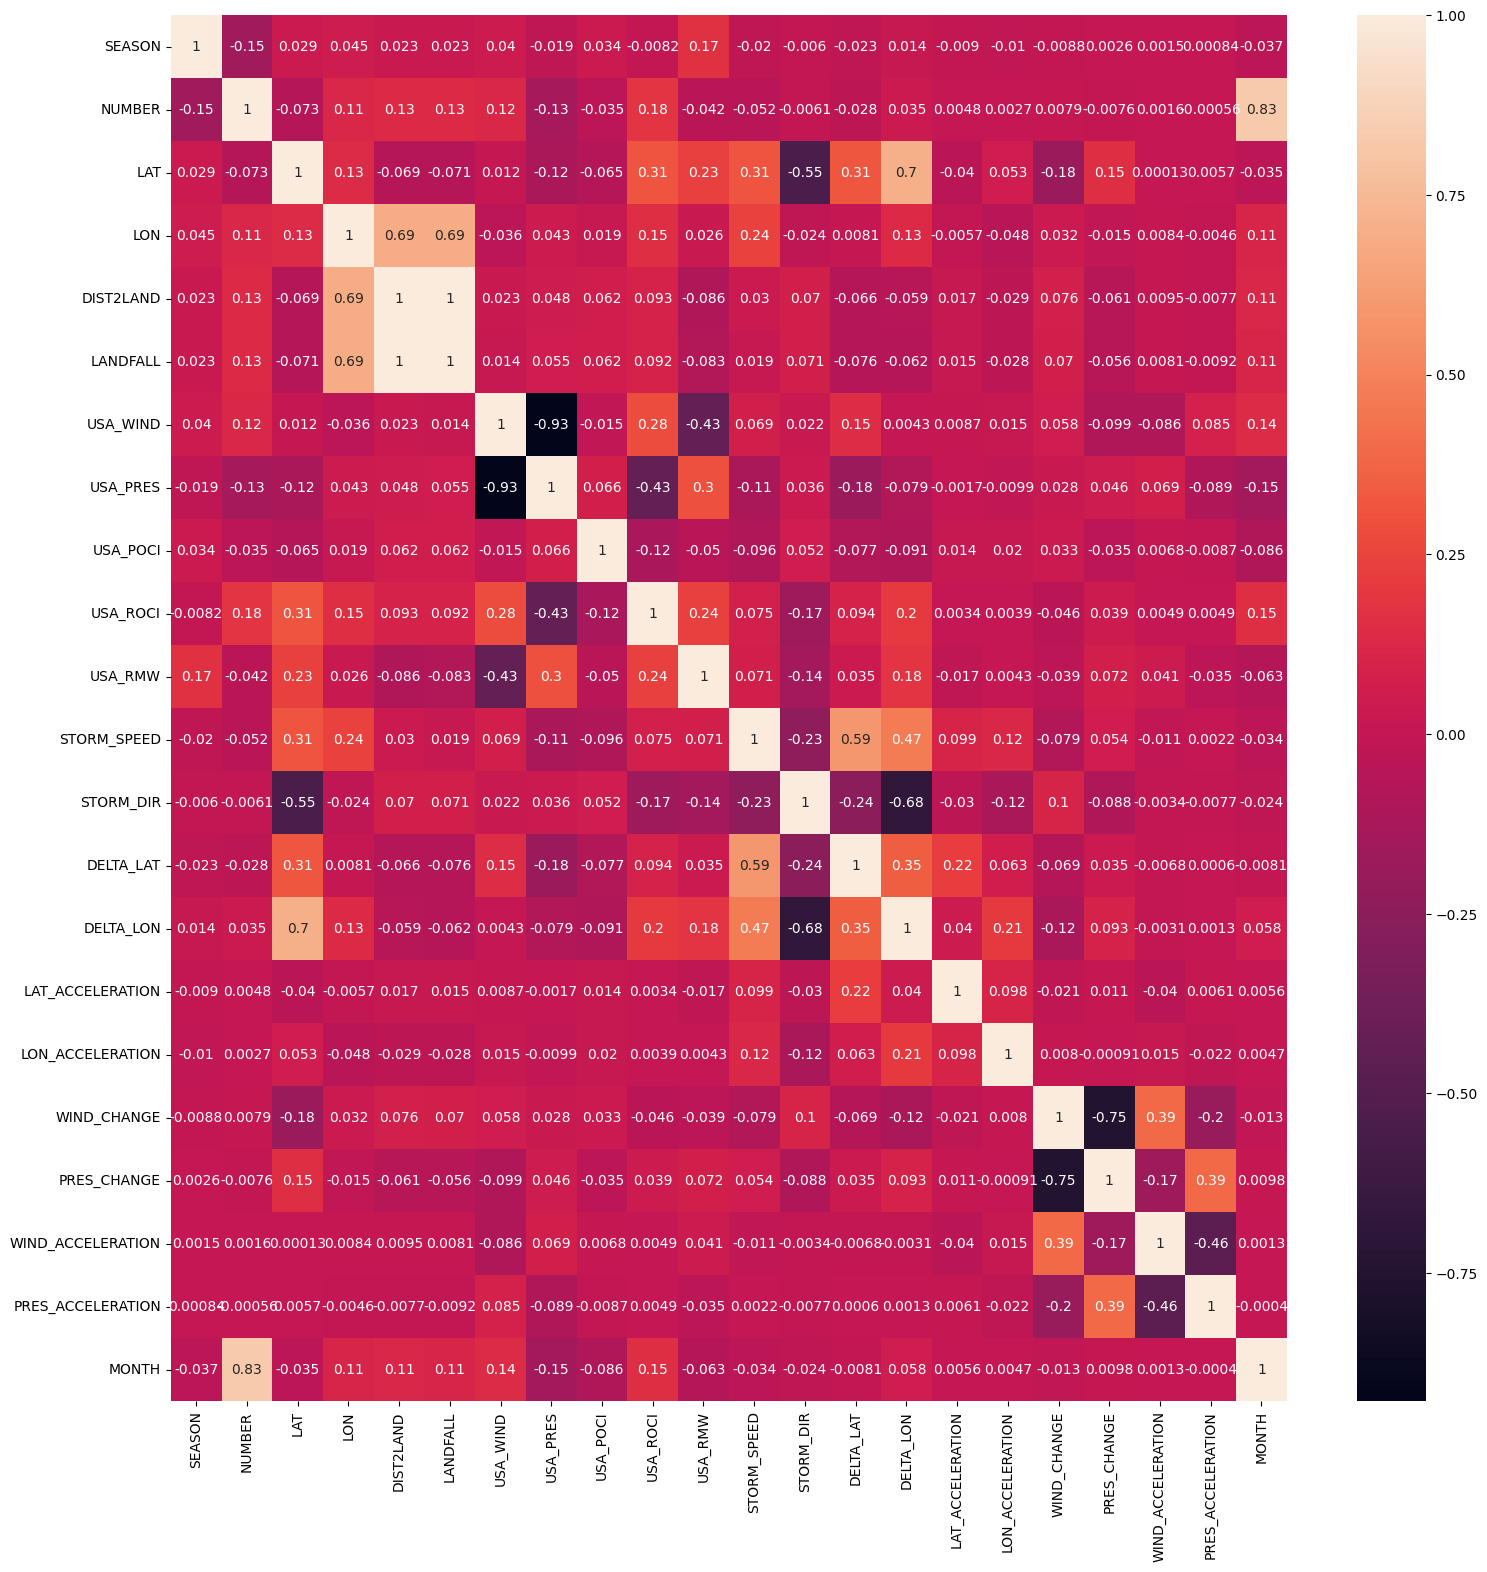

In [21]:
cont_features = hurricane_df.select_dtypes(["Int16", "float32"])
cat_features = hurricane_df.select_dtypes(["category", "datetime64[ns]", "string"])

cont_corr_matrix = hurricane_df[cont_features.columns].corr()

plt.figure(figsize= (18, 18))

sns.heatmap(cont_corr_matrix, annot=True)